# EDA, Preprocessing & Train/Val/Test Split

**Input:** `data/processed/merged_dataset.csv`  
**Outputs:**
- `data/processed/splits/X_train.csv`, `y_train.csv`
- `data/processed/splits/X_val.csv`,   `y_val.csv`
- `data/processed/splits/X_test.csv`,  `y_test.csv`
- `outputs/encoders/le_airline.pkl`, `le_origin.pkl`, `le_dest.pkl`, `scaler.pkl`

**Steps:**
1. Load merged dataset
2. EDA — weather correlation with delays
3. Encode categorical features (Label Encoding)
4. Scale numerical features (StandardScaler)
5. Stratified 70 / 15 / 15 train–val–test split
6. Handle class imbalance (Random Undersampling + class weights)
7. Save all split files and artefacts

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pickle

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.utils import resample

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

os.makedirs('../data/processed/splits', exist_ok=True)
os.makedirs('../outputs/encoders', exist_ok=True)
os.makedirs('../outputs/reports', exist_ok=True)

print('Libraries loaded.')

Libraries loaded.


## 1 — Load Merged Dataset

In [2]:
df = pd.read_csv('../data/processed/merged_dataset.csv')

print(f'Shape   : {df.shape}')
print(f'Columns : {list(df.columns)}')
print(f'\nDtypes:')
print(df.dtypes.to_string())
print(f'\nMissing values: {df.isnull().sum().sum()}')
df.head()

Shape   : (6965267, 13)
Columns : ['airline', 'origin', 'dest', 'distance', 'dep_hour', 'day_of_week', 'month', 'is_weekend', 'is_delayed', 'precipitation', 'temperature_c', 'humidity_pct', 'wind_speed_kmh']

Dtypes:
airline               str
origin                str
dest                  str
distance          float64
dep_hour            int64
day_of_week         int64
month               int64
is_weekend          int64
is_delayed          int64
precipitation     float64
temperature_c     float64
humidity_pct      float64
wind_speed_kmh    float64

Missing values: 0


,airline,origin,dest,distance,dep_hour,day_of_week,month,is_weekend,is_delayed,precipitation,temperature_c,humidity_pct,wind_speed_kmh
0,9E,JFK,DTW,509.0,12,1,1,0,0,5.099703,14.905590,60.748897,14.919450
1,9E,MSP,CLE,622.0,10,1,1,0,0,5.096906,14.803655,60.040201,15.007456
2,9E,JFK,RIC,288.0,14,1,1,0,0,5.081113,14.925762,58.949594,15.131454
3,9E,RIC,JFK,288.0,16,1,1,0,0,5.096906,14.803655,60.040201,15.007456
4,9E,DTW,MKE,237.0,10,1,1,0,0,5.096906,14.803655,60.040201,15.007456


## 2 — EDA: Weather Features vs Delay

### 2a — Correlation Heatmap

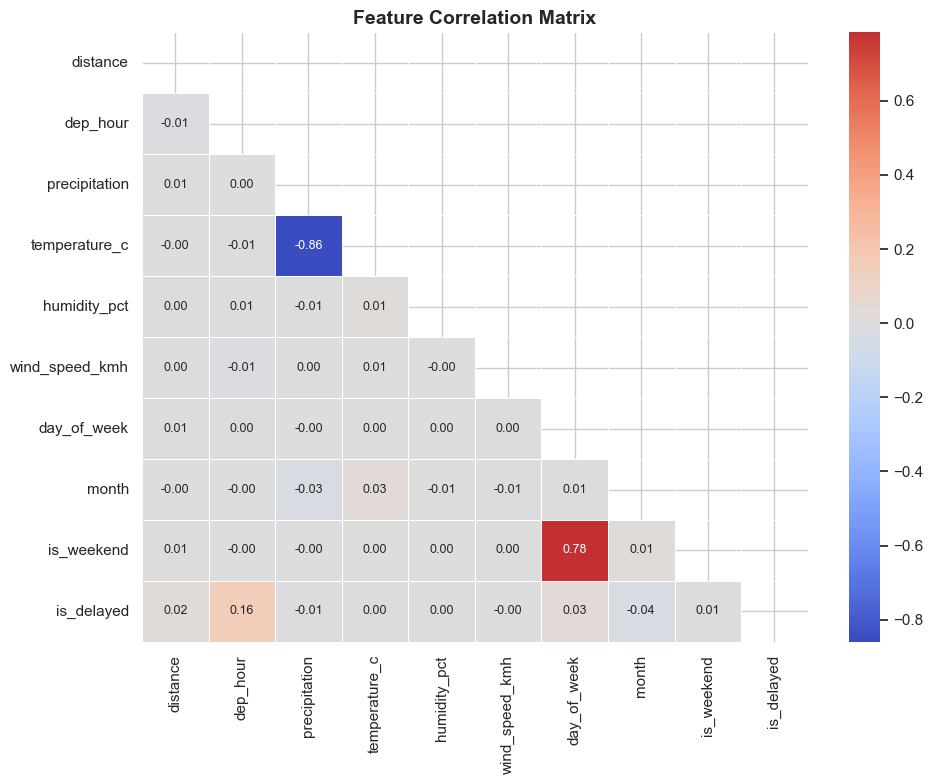

Saved: outputs/reports/correlation_heatmap.png


In [3]:
num_cols = ['distance', 'dep_hour', 'precipitation', 'temperature_c',
            'humidity_pct', 'wind_speed_kmh', 'day_of_week', 'month',
            'is_weekend', 'is_delayed']

corr = df[num_cols].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, linewidths=0.5,
    annot_kws={'size': 9}
)
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/reports/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/reports/correlation_heatmap.png')

### 2b — Delay Rate by Weather Conditions

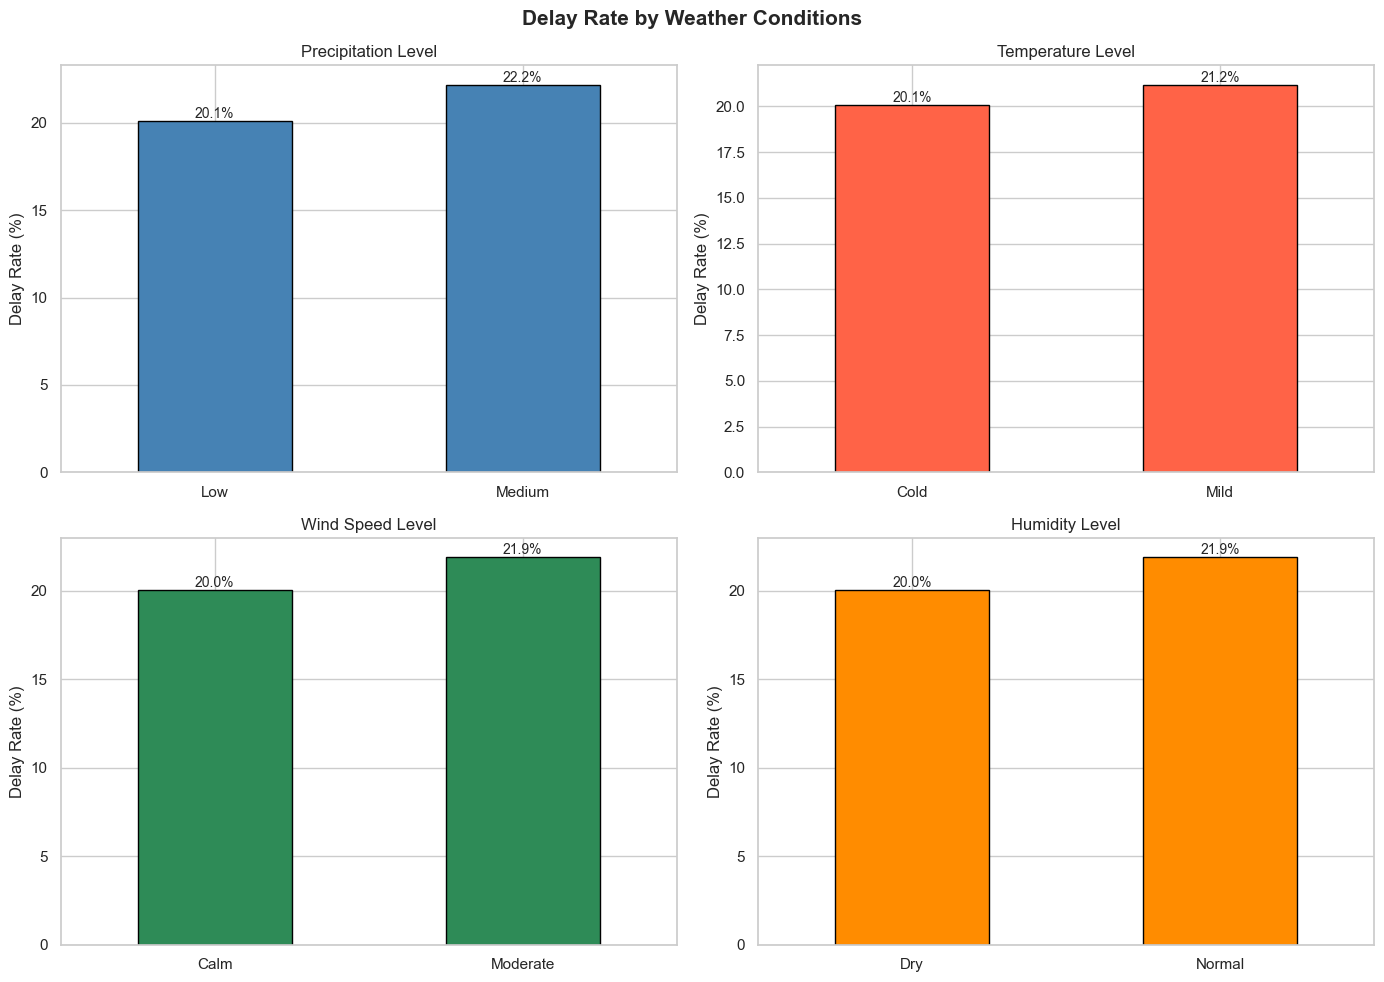

Saved: outputs/reports/eda_weather_delays.png


In [4]:
# Helper: trims labels to match however many bins actually get created
# Needed because ~85% of weather values are the same imputed mean,
# so pd.qcut may produce fewer than 3 bins after dropping duplicate edges
def safe_qcut(series, q, labels):
    _, bin_edges = pd.qcut(series, q=q, duplicates="drop", retbins=True)
    n_bins = len(bin_edges) - 1
    return pd.qcut(series, q=q, labels=labels[:n_bins], duplicates="drop")

df["precip_bin"] = safe_qcut(df["precipitation"],  3, ["Low",  "Medium",   "High"])
df["temp_bin"]   = safe_qcut(df["temperature_c"],  3, ["Cold", "Mild",     "Hot"])
df["wind_bin"]   = safe_qcut(df["wind_speed_kmh"], 3, ["Calm", "Moderate", "Windy"])
df["humid_bin"]  = safe_qcut(df["humidity_pct"],   3, ["Dry",  "Normal",   "Humid"])

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Delay Rate by Weather Conditions", fontsize=15, fontweight="bold")

bin_cols = [("precip_bin", "Precipitation Level", "steelblue"),
            ("temp_bin",   "Temperature Level",   "tomato"),
            ("wind_bin",   "Wind Speed Level",    "seagreen"),
            ("humid_bin",  "Humidity Level",      "darkorange")]

for ax, (col, title, color) in zip(axes.flat, bin_cols):
    rates = df.groupby(col, observed=True)["is_delayed"].mean() * 100
    rates.plot(kind="bar", ax=ax, color=color, edgecolor="black")
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("Delay Rate (%)")
    ax.tick_params(axis="x", rotation=0)
    for p in ax.patches:
        ax.annotate(f"{p.get_height():.1f}%",
                    (p.get_x() + p.get_width()/2, p.get_height()),
                    ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.savefig("../outputs/reports/eda_weather_delays.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/reports/eda_weather_delays.png")

# Drop bins - they were only for EDA
df.drop(columns=["precip_bin", "temp_bin", "wind_bin", "humid_bin"], inplace=True)


### 2c — Boxplots: Weather Features by Delay Class

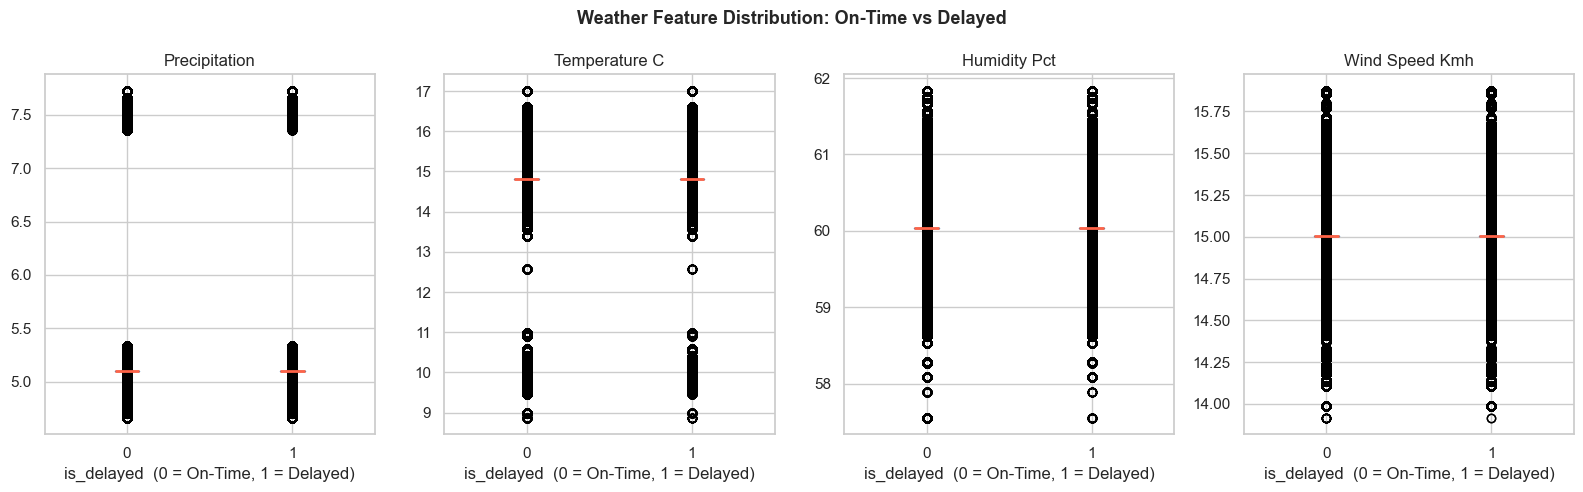

Saved: outputs/reports/eda_weather_boxplots.png


In [5]:
weather_features = ['precipitation', 'temperature_c', 'humidity_pct', 'wind_speed_kmh']

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
fig.suptitle('Weather Feature Distribution: On-Time vs Delayed', fontsize=13, fontweight='bold')

for ax, col in zip(axes, weather_features):
    df.boxplot(column=col, by='is_delayed', ax=ax,
               boxprops=dict(color='steelblue'),
               medianprops=dict(color='tomato', linewidth=2))
    ax.set_title(col.replace('_', ' ').title())
    ax.set_xlabel('is_delayed  (0 = On-Time, 1 = Delayed)')
    ax.set_ylabel('')

plt.suptitle('Weather Feature Distribution: On-Time vs Delayed', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/reports/eda_weather_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/reports/eda_weather_boxplots.png')

## 3 — Encode Categorical Features

| Column | Cardinality | Strategy |
|--------|-------------|----------|
| `airline` | ~20 | Label Encoding |
| `origin`  | ~300 | Label Encoding |
| `dest`    | ~300 | Label Encoding |
| `day_of_week` | 7 | Already integer (1–7) |
| `month`   | 12 | Already integer (1–12) |
| `is_weekend` | 2 | Already binary 0/1 |

> **Note for Student 4 (Mostafa):** Logistic Regression and distance-based models work better  
> with one-hot encoding for low-cardinality columns (airline, day_of_week, month).  
> Tree-based models (Random Forest, XGBoost) work fine with label-encoded integers.  
> The encoders saved here can be swapped out if needed.

In [6]:
cat_cols = ['airline', 'origin', 'dest']

encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le
    print(f'{col:<10}: {len(le.classes_)} unique classes → encoded to 0–{len(le.classes_)-1}')

# Persist encoders (needed to decode predictions at inference time)
for col, le in encoders.items():
    path = f'../outputs/encoders/le_{col}.pkl'
    with open(path, 'wb') as f:
        pickle.dump(le, f)
    print(f'Saved: {path}')

airline   : 15 unique classes → encoded to 0–14
origin    : 348 unique classes → encoded to 0–347
dest      : 348 unique classes → encoded to 0–347
Saved: ../outputs/encoders/le_airline.pkl
Saved: ../outputs/encoders/le_origin.pkl
Saved: ../outputs/encoders/le_dest.pkl


## 4 — Scale Numerical Features

In [7]:
num_scale_cols = ['distance', 'dep_hour', 'precipitation',
                  'temperature_c', 'humidity_pct', 'wind_speed_kmh']

print('=== Before Scaling ===')
print(df[num_scale_cols].describe().round(3).to_string())

scaler = StandardScaler()
df[num_scale_cols] = scaler.fit_transform(df[num_scale_cols])

print('\n=== After Scaling (mean≈0, std≈1) ===')
print(df[num_scale_cols].describe().round(3).to_string())

# Persist scaler
scaler_path = '../outputs/encoders/scaler.pkl'
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)
print(f'\nSaved: {scaler_path}')

=== Before Scaling ===
          distance     dep_hour  precipitation  temperature_c  humidity_pct  wind_speed_kmh
count  6965267.000  6965267.000    6965267.000    6965267.000   6965267.000     6965267.000
mean       810.525       12.992          5.097         14.804        60.040          15.007
std        530.048        4.898          0.165          0.365         0.204           0.102
min         11.000        0.000          4.664          8.873        57.553          13.918
25%        399.000        9.000          5.097         14.804        60.040          15.007
50%        680.000       13.000          5.097         14.804        60.040          15.007
75%       1069.000       17.000          5.097         14.804        60.040          15.007
max       2074.000       24.000          7.724         17.007        61.834          15.874

=== After Scaling (mean≈0, std≈1) ===
          distance     dep_hour  precipitation  temperature_c  humidity_pct  wind_speed_kmh
count  6965267.000

## 5 — Stratified 70 / 15 / 15 Split

In [8]:
feature_cols = [c for c in df.columns if c != 'is_delayed']
X = df[feature_cols]
y = df['is_delayed']

print(f'Features : {list(feature_cols)}')
print(f'X shape  : {X.shape}')
print(f'\nClass distribution before split:')
print(y.value_counts().to_string())

# Step 1: hold out 15% test set
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

# Step 2: from remaining 85%, hold out ~17.65% → gives 15% of total as validation
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=42, stratify=y_temp
)

print(f'\nSplit sizes:')
print(f'  Train : {len(X_train):>10,}  ({len(X_train)/len(X)*100:.1f}%)')
print(f'  Val   : {len(X_val):>10,}  ({len(X_val)/len(X)*100:.1f}%)')
print(f'  Test  : {len(X_test):>10,}  ({len(X_test)/len(X)*100:.1f}%)')

Features : ['airline', 'origin', 'dest', 'distance', 'dep_hour', 'day_of_week', 'month', 'is_weekend', 'precipitation', 'temperature_c', 'humidity_pct', 'wind_speed_kmh']
X shape  : (6965267, 12)

Class distribution before split:
is_delayed
0    5561879
1    1403388

Split sizes:
  Train :  4,875,511  (70.0%)
  Val   :  1,044,965  (15.0%)
  Test  :  1,044,791  (15.0%)


In [9]:
# Verify class ratio is preserved across all splits
for name, y_split in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    vc = y_split.value_counts(normalize=True) * 100
    print(f'{name:6}: on-time={vc.get(0, 0):.1f}%  delayed={vc.get(1, 0):.1f}%')

Train : on-time=79.9%  delayed=20.1%
Val   : on-time=79.9%  delayed=20.1%
Test  : on-time=79.9%  delayed=20.1%


## 6 — Handle Class Imbalance

The training set has an **~80/20 imbalance** (on-time vs delayed).  
We provide two complementary strategies:

| Strategy | How | When to use |
|----------|-----|-------------|
| **Random Undersampling** | Reduce majority class to 2× minority | Default — fast, good for trees |
| **Class Weights** | Tell the model to penalise minority errors more | Pass `class_weight` param directly to sklearn |

> **SMOTE** (synthetic oversampling) is conceptually superior but impractical here:  
> applying it to ~4.8M rows would require hours of compute and tens of GB of RAM.  
> Use Random Undersampling or class weights for this dataset size.

In [10]:
# --- Option A: Random Undersampling ---
# Combine X_train and y_train for resampling
train_data = X_train.copy()
train_data['is_delayed'] = y_train.values

majority = train_data[train_data['is_delayed'] == 0]
minority = train_data[train_data['is_delayed'] == 1]

print(f'Before undersampling:')
print(f'  Majority (on-time) : {len(majority):,}')
print(f'  Minority (delayed) : {len(minority):,}')
print(f'  Ratio              : {len(majority)/len(minority):.2f}:1')

# Undersample majority to 2× minority (2:1 ratio → more balanced, keeps more data than 1:1)
target_majority_size = len(minority) * 2
majority_downsampled = resample(
    majority,
    replace=False,
    n_samples=target_majority_size,
    random_state=42
)

train_balanced = pd.concat([majority_downsampled, minority]).sample(frac=1, random_state=42)

X_train_bal = train_balanced[feature_cols]
y_train_bal = train_balanced['is_delayed']

print(f'\nAfter undersampling (2:1 ratio):')
print(f'  Majority (on-time) : {(y_train_bal == 0).sum():,}')
print(f'  Minority (delayed) : {(y_train_bal == 1).sum():,}')
print(f'  Total train rows   : {len(X_train_bal):,}')
print(f'  Ratio              : {(y_train_bal==0).sum()/(y_train_bal==1).sum():.2f}:1')

Before undersampling:
  Majority (on-time) : 3,893,175
  Minority (delayed) : 982,336
  Ratio              : 3.96:1

After undersampling (2:1 ratio):
  Majority (on-time) : 1,964,672
  Minority (delayed) : 982,336
  Total train rows   : 2,947,008
  Ratio              : 2.00:1


In [11]:
# --- Option B: Class Weights (for use directly in sklearn models) ---
n_on_time = (y_train == 0).sum()
n_delayed  = (y_train == 1).sum()
n_total    = len(y_train)

# sklearn formula: weight[i] = n_total / (n_classes * n_samples_in_class_i)
w_on_time = n_total / (2 * n_on_time)
w_delayed  = n_total / (2 * n_delayed)

class_weights = {0: round(w_on_time, 4), 1: round(w_delayed, 4)}
print(f'Class weights: {class_weights}')
print()
print('Usage in sklearn models:')
print('  LogisticRegression(class_weight={0: ' + str(class_weights[0]) + ', 1: ' + str(class_weights[1]) + '})')
print('  RandomForestClassifier(class_weight={0: ' + str(class_weights[0]) + ', 1: ' + str(class_weights[1]) + '})')
print('  Or simply use class_weight="balanced" in any sklearn estimator')

# Save class weights for use in modeling notebook
with open('../outputs/encoders/class_weights.pkl', 'wb') as f:
    pickle.dump(class_weights, f)
print('\nSaved: outputs/encoders/class_weights.pkl')

Class weights: {0: np.float64(0.6262), 1: np.float64(2.4816)}

Usage in sklearn models:
  LogisticRegression(class_weight={0: 0.6262, 1: 2.4816})
  RandomForestClassifier(class_weight={0: 0.6262, 1: 2.4816})
  Or simply use class_weight="balanced" in any sklearn estimator

Saved: outputs/encoders/class_weights.pkl


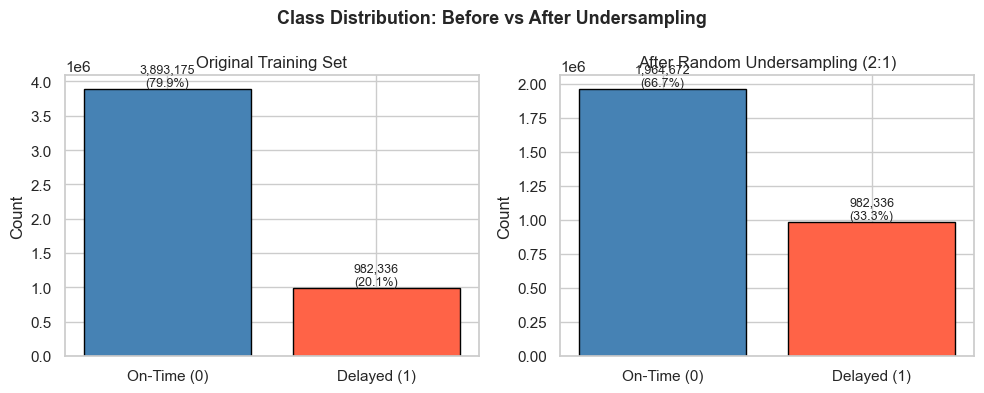

Saved: outputs/reports/class_balance_comparison.png


In [12]:
# Visualise before vs after class balance
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle('Class Distribution: Before vs After Undersampling', fontsize=13, fontweight='bold')

for ax, (y_data, title) in zip(axes, [
    (y_train,     'Original Training Set'),
    (y_train_bal, 'After Random Undersampling (2:1)')
]):
    vc = y_data.value_counts()
    ax.bar(['On-Time (0)', 'Delayed (1)'], [vc.get(0, 0), vc.get(1, 0)],
           color=['steelblue', 'tomato'], edgecolor='black')
    ax.set_title(title)
    ax.set_ylabel('Count')
    for p in ax.patches:
        ax.annotate(f'{p.get_height():,.0f}\n({p.get_height()/len(y_data)*100:.1f}%)',
                    (p.get_x() + p.get_width()/2, p.get_height()),
                    ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/reports/class_balance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/reports/class_balance_comparison.png')

## 7 — Save All Splits

In [13]:
splits = {
    'X_train': X_train_bal,          # balanced training features
    'y_train': y_train_bal,          # balanced training labels
    'X_val'  : X_val,                # validation features (untouched)
    'y_val'  : y_val,                # validation labels
    'X_test' : X_test,               # test features (untouched)
    'y_test' : y_test,               # test labels
}

base = '../data/processed/splits/'
for name, data in splits.items():
    path = f'{base}{name}.csv'
    data.to_csv(path, index=False)
    print(f'Saved {name:8}: {path}  shape={data.shape}')

Saved X_train : ../data/processed/splits/X_train.csv  shape=(2947008, 12)
Saved y_train : ../data/processed/splits/y_train.csv  shape=(2947008,)
Saved X_val   : ../data/processed/splits/X_val.csv  shape=(1044965, 12)
Saved y_val   : ../data/processed/splits/y_val.csv  shape=(1044965,)
Saved X_test  : ../data/processed/splits/X_test.csv  shape=(1044791, 12)
Saved y_test  : ../data/processed/splits/y_test.csv  shape=(1044791,)


## 8 — Final Summary

In [14]:
print('=' * 60)
print('PREPROCESSING COMPLETE — SUMMARY')
print('=' * 60)
print(f'\nFeature columns ({len(feature_cols)}):')
for col in feature_cols:
    print(f'  - {col}')

print(f'\nDataset splits:')
print(f'  X_train (balanced) : {X_train_bal.shape}   class ratio 2:1')
print(f'  X_val              : {X_val.shape}')
print(f'  X_test             : {X_test.shape}')

print(f'\nArtefacts saved:')
print(f'  outputs/encoders/le_airline.pkl')
print(f'  outputs/encoders/le_origin.pkl')
print(f'  outputs/encoders/le_dest.pkl')
print(f'  outputs/encoders/scaler.pkl')
print(f'  outputs/encoders/class_weights.pkl  → {class_weights}')

print(f'\nHandoff to Student 4 (Mostafa):')
print(f'  Load data/processed/splits/X_train.csv + y_train.csv to train models.')
print(f'  Evaluate on X_val/y_val; final score on X_test/y_test only.')
print(f'  Use class_weight=\"balanced\" or load class_weights.pkl for imbalance-aware models.')
print('=' * 60)

PREPROCESSING COMPLETE — SUMMARY

Feature columns (12):
  - airline
  - origin
  - dest
  - distance
  - dep_hour
  - day_of_week
  - month
  - is_weekend
  - precipitation
  - temperature_c
  - humidity_pct
  - wind_speed_kmh

Dataset splits:
  X_train (balanced) : (2947008, 12)   class ratio 2:1
  X_val              : (1044965, 12)
  X_test             : (1044791, 12)

Artefacts saved:
  outputs/encoders/le_airline.pkl
  outputs/encoders/le_origin.pkl
  outputs/encoders/le_dest.pkl
  outputs/encoders/scaler.pkl
  outputs/encoders/class_weights.pkl  → {0: np.float64(0.6262), 1: np.float64(2.4816)}

Handoff to Student 4 (Mostafa):
  Load data/processed/splits/X_train.csv + y_train.csv to train models.
  Evaluate on X_val/y_val; final score on X_test/y_test only.
  Use class_weight="balanced" or load class_weights.pkl for imbalance-aware models.
